<div style=" background-color: #439cc8;border-radius: 8px;font-size:2.5rem;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">NOTEBOOK 2</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Modélisation simple
</h2>
</div>


<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">1 - Préparation des données</h2>
</div>


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.1 - Import des modules et acquisition des données</h3>
</div>


In [1]:
# Importations de bibliothèques standard
import os
import time
import re
import joblib
import pickle

# Importations de bibliothèques de traitement des données
import pandas as pd
import numpy as np

# Importations de bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Importations de bibliothèques de machine learning
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

import shap

# Option pour afficher tout le contenu
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 999)

# Chargement des données
my_path = r"D:/ENI/CHAPITRE_10/used_cars_germany/" #A modifier
data_path = os.path.join(my_path,"data_clean.parquet")
df = pd.read_parquet(data_path, engine="pyarrow")

# Affichage des premières lignes du dataframe
df.head()


,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
0,alfa-romeo,Alfa Romeo 147,blue,2005-10-01,2005,185,Manual,Petrol,126000,Brera,10599,287.0,12.1,10
1,alfa-romeo,Alfa Romeo Spider,blue,2005-06-01,2005,166,Manual,Petrol,203997,2.0 JTS Edizione 2005,5900,220.0,9.2,6
2,alfa-romeo,Alfa Romeo GT,grey,2005-06-01,2005,241,Manual,Petrol,143800,"3.2 V6 24V Distinctive Alfa-Scheckheft,1.Hand",17980,295.0,12.4,6
3,alfa-romeo,Alfa Romeo GT,grey,2005-09-01,2005,166,Manual,Petrol,219000,2.0 16V JTS Distinctive Leder Bose LM ATM,2000,207.0,8.7,9
4,alfa-romeo,Alfa Romeo GT,grey,2005-10-01,2005,241,Manual,Petrol,130260,"3.2 V6 24V Distinctive, LEDER, aAC, TEMPO,PDC",7990,295.0,12.4,10


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.2 - Contrôles</h3>
</div>


In [2]:
df.describe(include=["object", "category"])

,brand,model,color,transmission_type,fuel_type,version
count,185248,185248,185248,185248,185248,185248
unique,44,1037,14,3,6,152489
top,volkswagen,Volkswagen Golf,black,Automatic,Petrol,Titanium
freq,24391,5650,41968,94117,105829,161


In [3]:
df.brand.value_counts().tail(15)

brand
maserati        175
lada            145
isuzu           138
daihatsu        117
cadillac         78
saab             77
infiniti         74
chevrolet        73
dodge            64
lancia           59
bentley          16
aston-martin     10
daewoo            9
rover             3
chrysler          1
Name: count, dtype: int64

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Certaines marques ont de trop faibles effectifs</p>
</div>


In [4]:
df.transmission_type.value_counts()

transmission_type
Automatic         94117
Manual            90949
Semi-automatic      182
Name: count, dtype: int64

In [5]:
df.fuel_type.value_counts()

fuel_type
Petrol           105829
Diesel            64550
Hybrid             9007
Electric           4849
LPG                 710
Diesel Hybrid       303
Name: count, dtype: int64

In [6]:
df.color.value_counts()

color
black     41968
grey      35110
white     31114
silver    24155
blue      23197
red       16903
brown      3454
orange     2787
green      2263
beige      1848
yellow     1309
gold        426
bronze      415
violet      299
Name: count, dtype: int64

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.3 - Filtrage des marques dont les effectifs sont inférieurs à 50</h3>
</div>


In [7]:
# Comptage des occurrences de chaque marque
brand_counts = df["brand"].value_counts()

# Filtrage des marques avec plus de 50 occurrences
brands_above_50 = brand_counts[brand_counts > 50].index.tolist()

# Filtrage des données
df = df[df["brand"].isin(brands_above_50)].copy()

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">2 - Modélisation</h2>
</div>


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.1 - Préparation des données</h3>
</div>


In [8]:
# Définir les variables indépendantes et cibles
# Liste des variables numériques et catégorielles
num_features = ["year", "power_ps", "fuel_consumption_g_km_num", "mileage_in_km"]
cat_features = ["brand", "transmission_type", "fuel_type", "color"]

# Sélectionner les colonnes pour le modèle
X = df[num_features + cat_features].copy()

# Définir la variable cible (le prix)
y = df["price"]

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Encodage OneHot pour les variables catégorielles
encoder = OneHotEncoder(drop=None, sparse_output=False)

# Normalisation des variables numériques
scaler = StandardScaler()

# Transformation des colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, num_features),  # Standardisation des variables numériques
        ("cat", encoder, cat_features),  # Encodage OneHot des variables catégorielles
    ],
    remainder="drop",  # On ignore les autres colonnes non spécifiées
)

# Pipeline de prétraitement
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Ajuster et transformer les données d'entraînement
X_train_transformed = preprocessing_pipeline.fit_transform(X_train)

# Transformer les données de test
X_test_transformed = preprocessing_pipeline.transform(X_test)


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.2 - Tests</h3>
</div>


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.1 - DummyRegressor</h4>
</div>


In [9]:
# Dummy Regressor (modèle de référence)
dummy_model = DummyRegressor(strategy="mean")  # Utiliser la moyenne pour prédire
dummy_model.fit(X_train_transformed, y_train)
y_dummy_pred = dummy_model.predict(X_test_transformed)

# Évaluation du DummyRegressor
dummy_mse = mean_squared_error(y_test, y_dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_mae = mean_absolute_error(y_test, y_dummy_pred)
dummy_r2 = dummy_model.score(X_test_transformed, y_test)

print(f"Dummy Regressor - RMSE: {dummy_rmse:.2f}")
print(f"Dummy Regressor - MAE: {dummy_mae:.2f}")
print(f"Dummy Regressor - R-squared (R²): {dummy_r2:.2f}")

Dummy Regressor - RMSE: 11628.83
Dummy Regressor - MAE: 9294.52
Dummy Regressor - R-squared (R²): -0.00


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 L'erreur moyenne du modèle Dummy, qui sert de point de comparaison, est de 9282 euros.</p>
    <p>Ainsi, en utilisant uniquement la moyenne, nous trouvons le prix, en moyenne, à 9282 euros près.</p>
    <p>Son score est de 0 car il s'appuie uniquement sur la moyenne.</p>
</div>


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.2 - SVR (Support Vector Machine Regressor)</h4>
</div>


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>❌ Le SVR n'a pas aboutit</p>
</div>


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.3 - RandomForestRegressor</h4>
</div>


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>❌ Le temps d'exécution du RandomForestRegressor était particulièrement long (5900 secondes)</p>
    <p>Les paramètres étaient les suivants : </p>
    <p>{
    'regressor': [RandomForestRegressor()],
    'regressor__n_estimators': [100],
    'regressor__max_depth': [None, 10],
}</p>
    <p>Après quelques essais préliminaires, nous allons mettre en place un pipeline pour tester différents algorithmes avec différentes combinaisons</p>
</div>


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.3 - Pipeline</h3>
</div>


In [ ]:
# Nombre de cœurs logiques (threads)
num_cores = os.cpu_count()
print(f"Nombre de cœurs disponibles : {num_cores}")


Nombre de cœurs disponibles : 12


In [ ]:
start_time = time.time()

,regressor,params_clean,mean_test_score,std_test_score,rank_test_score
6,HistGradientBoostingRegressor,"{'learning_rate': 0.1, 'max_depth': None, 'max_iter': 700}",0.886135,0.001600,1
5,HistGradientBoostingRegressor,"{'learning_rate': 0.1, 'max_depth': None, 'max_iter': 500}",0.885288,0.001703,2
8,HistGradientBoostingRegressor,"{'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 700}",0.885216,0.002488,3
12,HistGradientBoostingRegressor,"{'learning_rate': 0.07, 'max_depth': 10, 'max_iter': 700}",0.885026,0.001615,4
10,HistGradientBoostingRegressor,"{'learning_rate': 0.07, 'max_depth': None, 'max_iter': 700}",0.884908,0.001608,5
7,HistGradientBoostingRegressor,"{'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 500}",0.884661,0.002211,6
9,HistGradientBoostingRegressor,"{'learning_rate': 0.07, 'max_depth': None, 'max_iter': 500}",0.883504,0.001702,7
11,HistGradientBoostingRegressor,"{'learning_rate': 0.07, 'max_depth': 10, 'max_iter': 500}",0.883097,0.001650,8
4,KNeighborsRegressor,{'n_neighbors': 5},0.853607,0.001999,9
3,KNeighborsRegressor,{'n_neighbors': 2},0.830147,0.001535,10



Modèle : HistGradientBoostingRegressor
Score : 0.886
RMSE : 3871.09
MAE : 2482.95


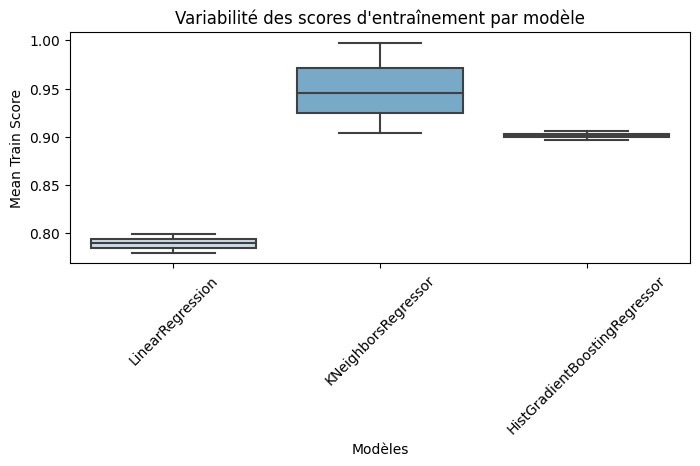

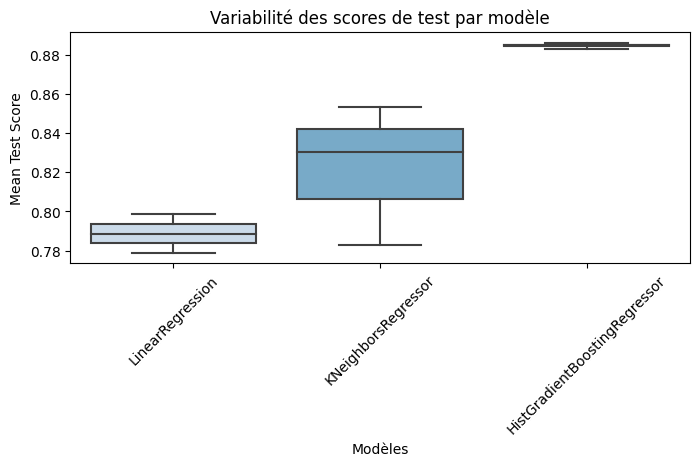

In [ ]:
# Variable cible
y = df["price"]

# Variables explicatives
num_features = ["year", "power_ps", "fuel_consumption_g_km_num", "mileage_in_km"]

categorical_features = ["brand", "transmission_type", "fuel_type", "color"]

X = df[num_features + categorical_features]

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Définition du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features,
        ),  # Appliquer le scaler aux caractéristiques numériques
        (
            "cat",
            OneHotEncoder(drop="first", sparse=False),
            categorical_features,
        ),  # Binariser les variables catégorielles
    ]
)

# Mise à jour des paramètres pour utiliser HistGradientBoosting
param_grid = [
    {"regressor": [LinearRegression()], "regressor__fit_intercept": [True, False]},
    {"regressor": [KNeighborsRegressor()], "regressor__n_neighbors": [1, 2, 5]},
    {
        "regressor": [HistGradientBoostingRegressor(random_state=42)],
        "regressor__max_iter": [500, 700],
        "regressor__max_depth": [None, 10],
        "regressor__learning_rate": [0.1, 0.07],
    },
]


# Création d'un pipeline incluant les transformations
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),  # Prétraitement
        ("regressor", LinearRegression()),  # Modèle par défaut
    ]
)

# Création de la GridSearchCV
grid_search = GridSearchCV(
    pipeline, param_grid, cv=3, return_train_score=True, n_jobs=8
)

# Entraînement
grid_search.fit(X_train, y_train)

##################### Affichage des résultats par simulation ####################################

# Récupération des résultats dans un DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Extraction du nom de l'algorithme et nettoyage des hyperparamètres
results["regressor"] = results["param_regressor"].apply(
    lambda x: re.sub(r"\s*\(.*?\)", "", str(type(x).__name__))
)

# Nettoyage de params_clean
results["params_clean"] = results["params"].apply(
    lambda d: {
        k.replace("regressor__", ""): v for k, v in d.items() if "regressor__" in k
    }
)

# Colonnes à conserver
cols_to_keep = [
    "regressor",
    "params_clean",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

# Réorganisation des colonnes
results_clean = results[cols_to_keep].sort_values("rank_test_score")

display(results_clean)

##################### fin de affichage des résultats par simulation ##############################

# Calcul de la MAE et RMSE pour le meilleur modèle
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

# Affichage des résultats
bm = best_model.named_steps["regressor"].__class__.__name__
print(f"\nModèle : {bm}")
print(f"Score : {grid_search.best_score_:.3f}")
print(f"RMSE : {rmse_best:.2f}")
print(f"MAE : {mae_best:.2f}")

# Création des boxplots pour évaluer la variabilité du score d'entraînement
plt.figure(figsize=(8, 3))
sns.boxplot(data=results, x="regressor", y="mean_train_score", palette="Blues")
plt.title("Variabilité des scores d'entraînement par modèle")
plt.xlabel("Modèles")
plt.ylabel("Mean Train Score")
plt.xticks(rotation=45)
plt.show()

# Création des boxplots pour évaluer la variabilité du score de test
plt.figure(figsize=(8, 3))
sns.boxplot(data=results, x="regressor", y="mean_test_score", palette="Blues")
plt.title("Variabilité des scores de test par modèle")
plt.xlabel("Modèles")
plt.ylabel("Mean Test Score")
plt.xticks(rotation=45)
plt.show()


In [ ]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")


Temps d'exécution pour : 393.81 secondes


In [ ]:
# Calcul de la MAE et RMSE pour le meilleur modèle
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

# Affichage des résultats
bm = best_model.named_steps["regressor"].__class__.__name__
print(f"\nModèle : {bm}")
print(f"Score : {grid_search.best_score_:.3f}")
print(f"RMSE : {rmse_best:.2f}")
print(f"MAE : {mae_best:.2f}")



Modèle : HistGradientBoostingRegressor
Score : 0.886
RMSE : 3871.09
MAE : 2482.95


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 HistGradientBoostingRegressor est le meilleur modèle.</p>
    <p>La procédure complète a duré environ 6 minutes</p>
    <p>Grâce à lui, nous trouvons, en moyenne, le prix à 2482.95 euros près soit une réduction de l'erreur de prédiction de 73.2% comparé au DummyRegressor.</p>
</div>


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.4 - Feature importance avec SHAP</h3>
</div>


100%|===================| 56521/56563 [11:16<00:00]        

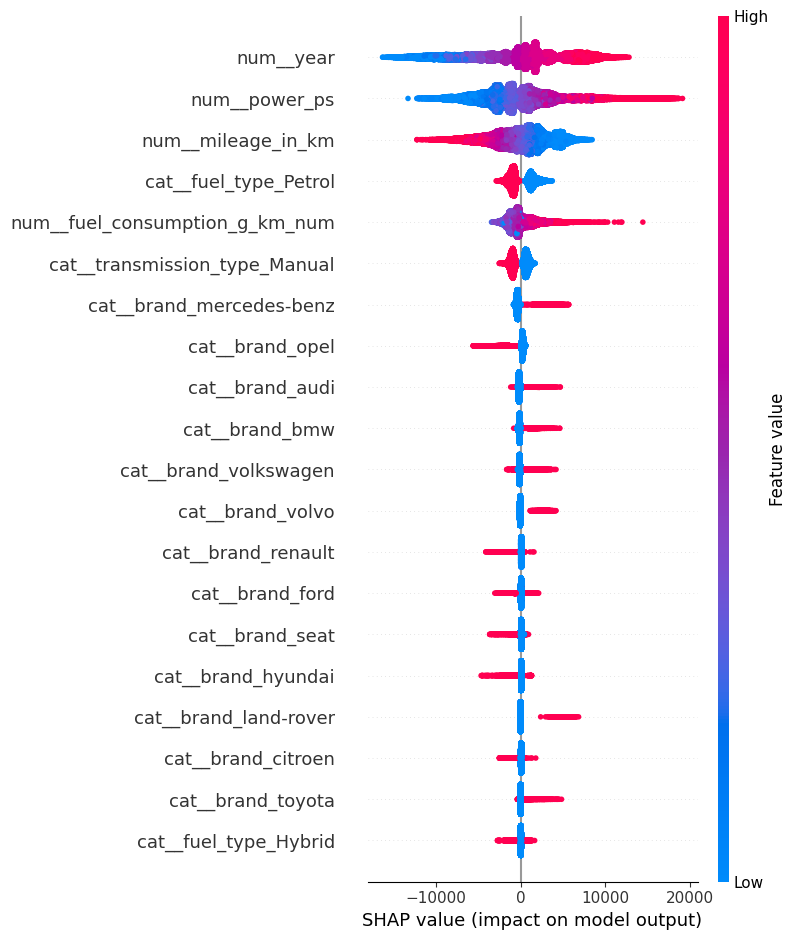

In [ ]:
# Création d'un explainer SHAP
explainer = shap.Explainer(
    best_model.named_steps["regressor"],
    best_model.named_steps["preprocessor"].transform(X_train),
)

# Calcul des valeurs SHAP
shap_values = explainer(
    best_model.named_steps["preprocessor"].transform(X_test), check_additivity=False
)

# Extraction des noms des caractéristiques
preprocessor = best_model.named_steps["preprocessor"]
cols_names = preprocessor.get_feature_names_out()

# Visualisation de  l'importance des caractéristiques
shap.summary_plot(
    shap_values,
    best_model.named_steps["preprocessor"].transform(X_test),
    feature_names=cols_names,
)


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Feature importance de SHAP</p>
    <p>Ce module Python nous permet d'analyser, par ordre décroissant d'importance, les variables du système.</p>
    <p>L'année, la puissance et le kilométrage occupent les trois premières places.</p>
    <p>Certaines marques comme Mercedes, Audi ou BMW, contribuent à pousser le prix à la hausse. D'autres, comme Seat ou Opel, produisent l'effet inverse.</p>
</div>


                           feature   importance
0                        num__year  4728.198185
1                    num__power_ps  3611.503270
3               num__mileage_in_km  2633.862837
48           cat__fuel_type_Petrol  1250.349710
2   num__fuel_consumption_g_km_num  1214.534628
42   cat__transmission_type_Manual   847.433701
26        cat__brand_mercedes-benz   643.023333
30                 cat__brand_opel   393.879171
4                  cat__brand_audi   352.908801
5                   cat__brand_bmw   251.304442
40           cat__brand_volkswagen   238.192144
41                cat__brand_volvo   130.010841
33              cat__brand_renault   123.884441
13                 cat__brand_ford   108.440200
35                 cat__brand_seat    99.021857
15              cat__brand_hyundai    83.863344
23           cat__brand_land-rover    78.573926
8               cat__brand_citroen    62.822444
39               cat__brand_toyota    57.391601
46           cat__fuel_type_Hybrid    57

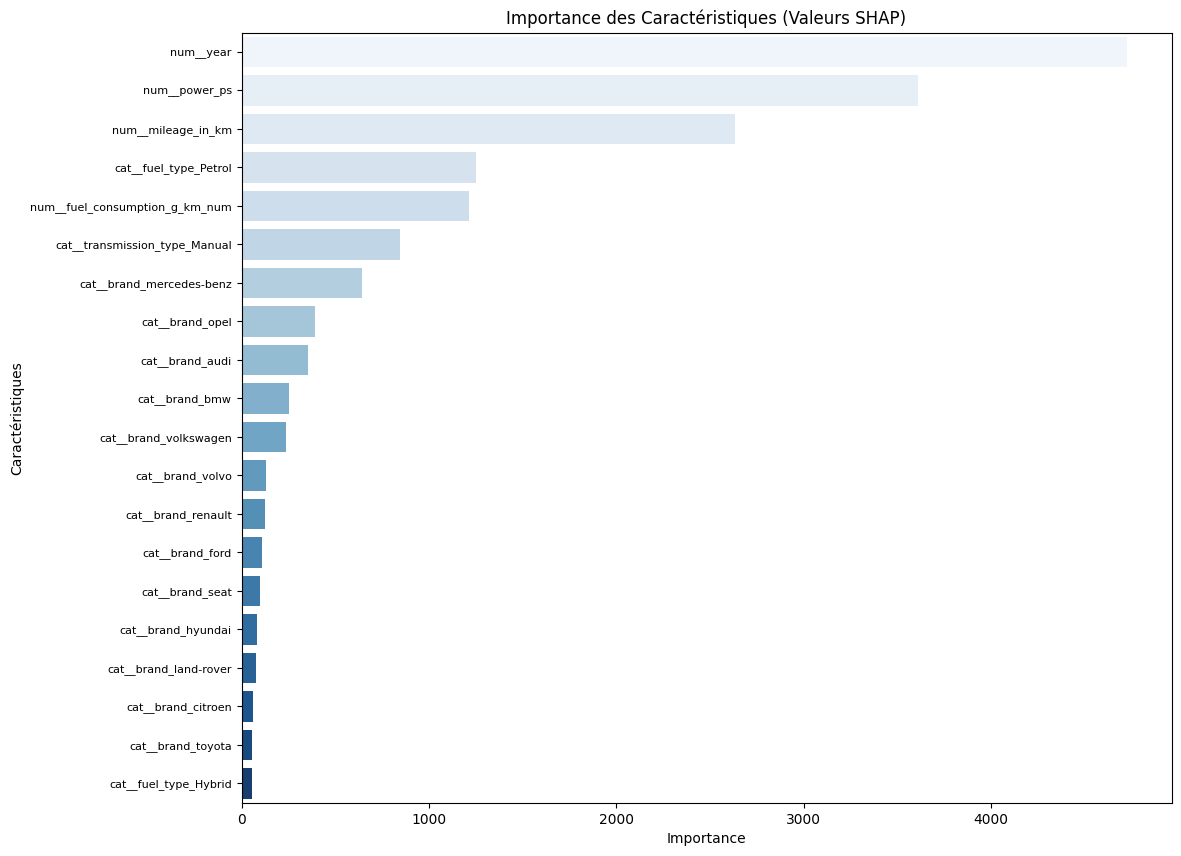

In [ ]:
# Calculer l'importance moyenne des caractéristiques
importance_df = pd.DataFrame(
    {
        "feature": best_model.named_steps["preprocessor"].get_feature_names_out(),
        "importance": np.abs(shap_values.values).mean(axis=0),
    }
)

# Trier par importance décroissante (les 20 premières)
importance_df = importance_df.sort_values(by="importance", ascending=False)[:20]

# Afficher l'importance des caractéristiques
print(importance_df)


# Visualiser l'importance des caractéristiques avec un bar plot
plt.figure(figsize=(12, 10))
ax = sns.barplot(data=importance_df, x="importance", y="feature", palette="Blues")
plt.title("Importance des Caractéristiques (Valeurs SHAP)")
plt.xlabel("Importance")
plt.ylabel("Caractéristiques")

# Modifier la taille de la police de l'axe y
ax.set_yticklabels(
    ax.get_yticklabels(), fontsize=8
)  # Ajuster 'fontsize' selon vos préférences

plt.show()


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Le code précédent nous permet d'évaluer le feature importance global du système décisionnel.</p>
    <p>La représentation en barres permet de bien mesurer l'importance de chaque variable.</p>
</div>


<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">3 - Sauvegarde du modèle</h2>
</div>


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.1 - Avec Joblib</h3>
</div>


In [ ]:
# Enregistrement du pipeline complet (meilleur modèle)
joblib.dump(best_model, "best_model_pipeline.pkl")

# Chargement du pipeline complet plus tard
best_model_loaded = joblib.load("best_model_pipeline.pkl")


['best_model_pipeline.pkl']

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.2 - Avec Pickle</h3>
</div>


In [ ]:
# Enregistrement du pipeline complet (meilleur modèle)
with open("best_model_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Chargement du pipeline complet plus tard
with open("best_model_pipeline.pkl", "rb") as f:
    best_model_loaded = pickle.load(f)
